In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle
import joblib
import pandas as pd
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, precision_score,
                             recall_score)
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Load data
with open('data/processed/data_splits.pkl', 'rb') as f:
    data = pickle.load(f)

classes = data['classes']
test_paths = data['test_paths']
test_labels = data['test_labels']
train_labels = data['train_labels']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Everything loaded!")
print(f"Test samples: {len(test_paths)}")
print(f"Classes: {len(classes)}")

Everything loaded!
Test samples: 3096
Classes: 15


In [2]:
class PlantDiseaseDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_dataset = PlantDiseaseDataset(test_paths, test_labels, transform=val_transform)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

# Load balanced model
model = models.resnet50(weights=None)
model.fc = nn.Linear(2048, len(classes))
model.load_state_dict(torch.load('models/resnet50_balanced.pth', map_location='cpu'))
model = model.to(device)
model.eval()

print("Running evaluation on test set...")
all_preds, all_true = [], []
all_probs = []

with torch.no_grad():
    for i, (images, labels) in enumerate(test_loader):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_true.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        if (i+1) % 20 == 0:
            print(f"  Batch {i+1}/{len(test_loader)} done...")

all_preds = np.array(all_preds)
all_true  = np.array(all_true)
all_probs = np.array(all_probs)

print(f"\nTest Accuracy:        {accuracy_score(all_true, all_preds)*100:.2f}%")
print(f"F1 Score (macro):     {f1_score(all_true, all_preds, average='macro'):.4f}")
print(f"F1 Score (weighted):  {f1_score(all_true, all_preds, average='weighted'):.4f}")
print(f"Precision (macro):    {precision_score(all_true, all_preds, average='macro'):.4f}")
print(f"Recall (macro):       {recall_score(all_true, all_preds, average='macro'):.4f}")

Running evaluation on test set...
  Batch 20/97 done...
  Batch 40/97 done...
  Batch 60/97 done...
  Batch 80/97 done...

Test Accuracy:        99.74%
F1 Score (macro):     0.9972
F1 Score (weighted):  0.9974
Precision (macro):    0.9969
Recall (macro):       0.9976


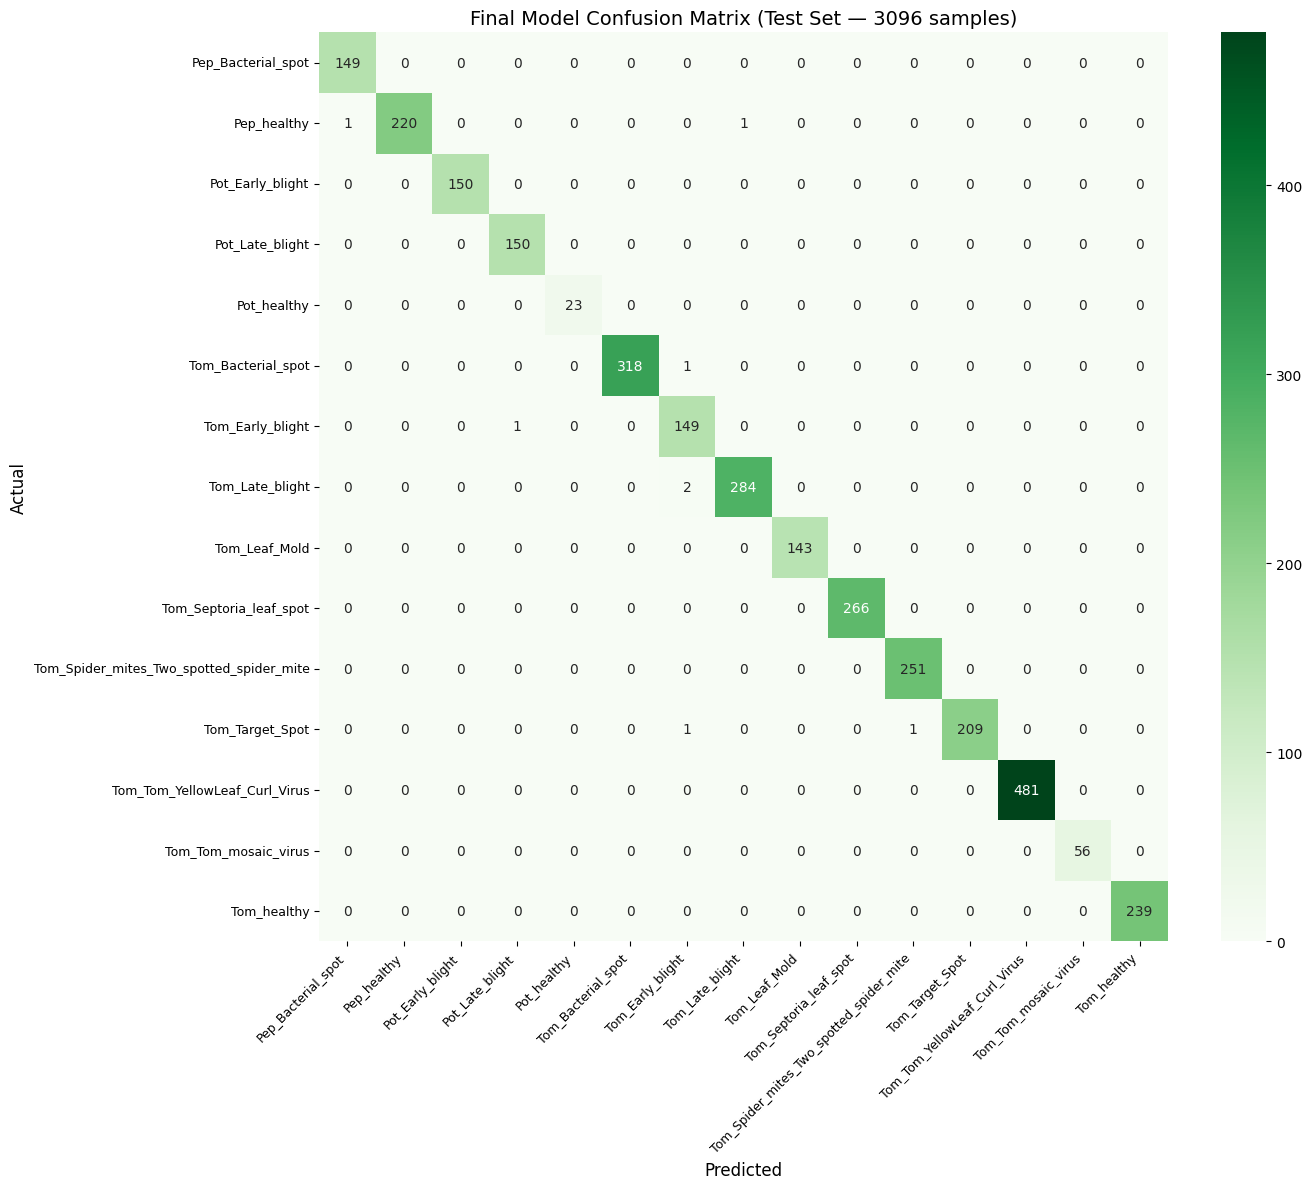

Saved!


In [3]:
# Short class names for readability
short_names = [c.replace('Tomato_', 'Tom_')
                .replace('Potato___', 'Pot_')
                .replace('Pepper__bell___', 'Pep_')
                .replace('__', '_') for c in classes]

plt.figure(figsize=(14, 12))
cm = confusion_matrix(all_true, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=short_names,
            yticklabels=short_names)
plt.title('Final Model Confusion Matrix (Test Set — 3096 samples)', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('outputs/final_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

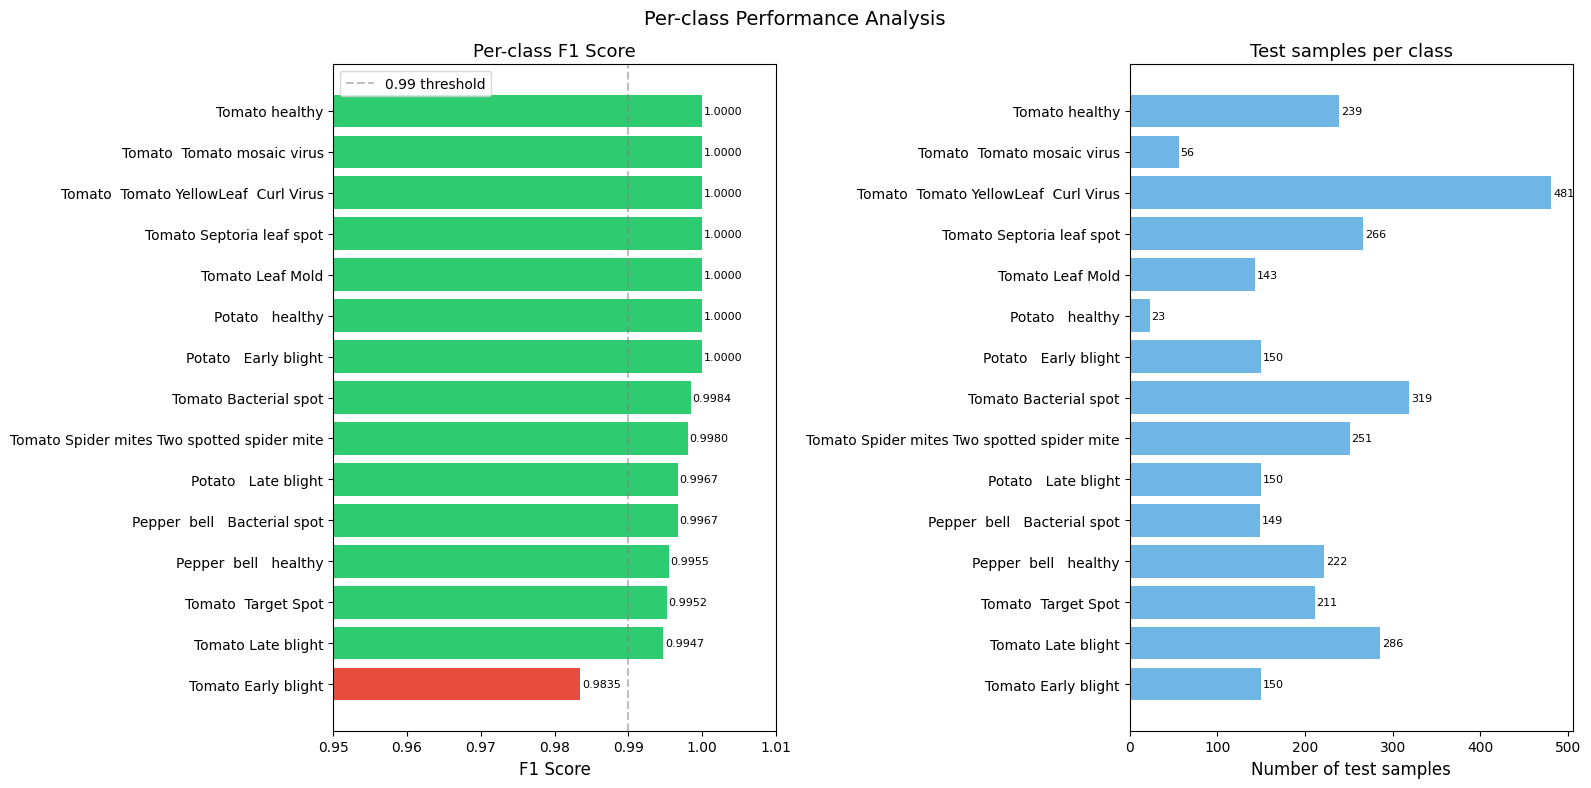

Saved to outputs/per_class_performance.png


In [4]:
# Per-class F1 scores
report = classification_report(all_true, all_preds, 
                                target_names=classes, output_dict=True)

class_f1 = [(cls, report[cls]['f1-score'], report[cls]['support']) 
             for cls in classes]
class_f1.sort(key=lambda x: x[1])

names = [c[0].replace('_', ' ') for c in class_f1]
f1_scores = [c[1] for c in class_f1]
supports = [c[2] for c in class_f1]
colors = ['#e74c3c' if f < 0.99 else '#2ecc71' for f in f1_scores]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# F1 scores
bars = ax1.barh(names, f1_scores, color=colors)
ax1.set_xlim([0.95, 1.01])
ax1.set_xlabel('F1 Score', fontsize=12)
ax1.set_title('Per-class F1 Score', fontsize=13)
ax1.axvline(x=0.99, color='gray', linestyle='--', alpha=0.5, label='0.99 threshold')
ax1.legend()
for bar, score in zip(bars, f1_scores):
    ax1.text(score + 0.0002, bar.get_y() + bar.get_height()/2,
             f'{score:.4f}', va='center', fontsize=8)

# Support (sample count)
ax2.barh(names, supports, color='#3498db', alpha=0.7)
ax2.set_xlabel('Number of test samples', fontsize=12)
ax2.set_title('Test samples per class', fontsize=13)
for bar, sup in zip(ax2.patches, supports):
    ax2.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
             str(int(sup)), va='center', fontsize=8)

plt.suptitle('Per-class Performance Analysis', fontsize=14)
plt.tight_layout()
plt.savefig('outputs/per_class_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/per_class_performance.png")

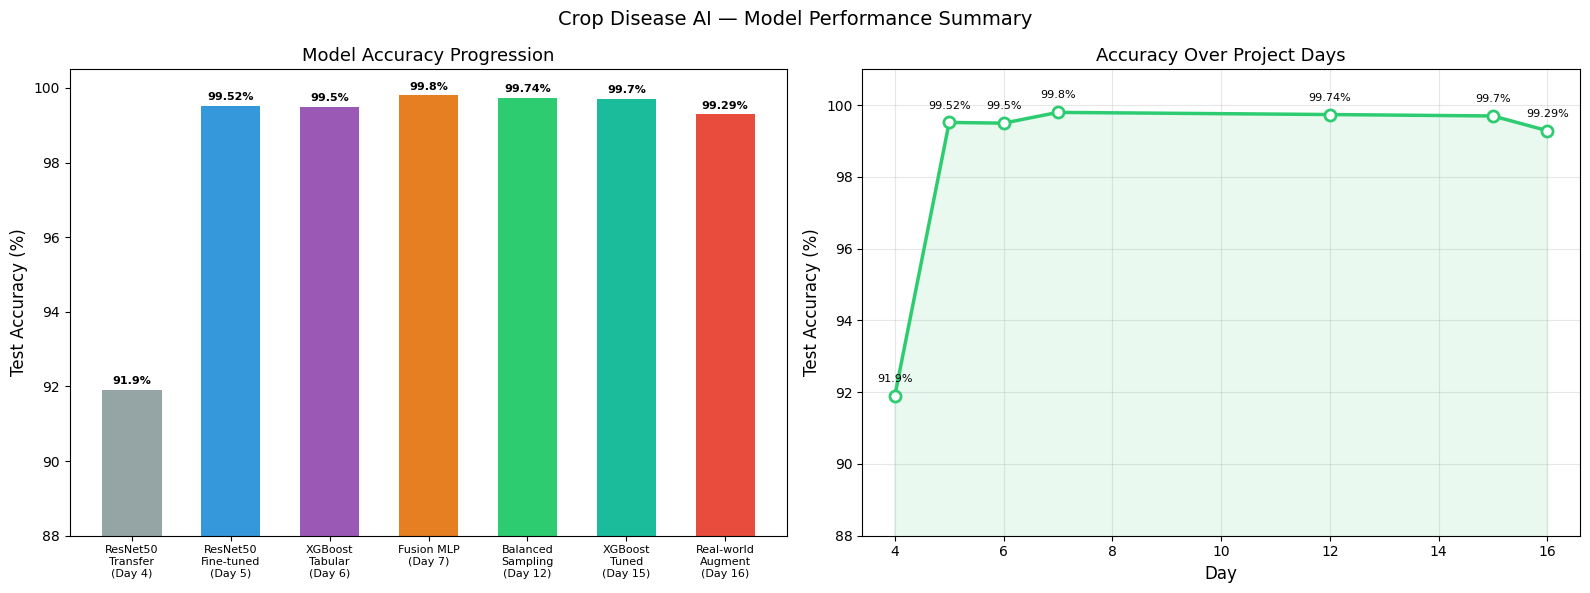

Saved to outputs/model_progression.png


In [5]:
# Model progression chart
model_names = [
    'ResNet50\nTransfer\n(Day 4)',
    'ResNet50\nFine-tuned\n(Day 5)',
    'XGBoost\nTabular\n(Day 6)',
    'Fusion MLP\n(Day 7)',
    'Balanced\nSampling\n(Day 12)',
    'XGBoost\nTuned\n(Day 15)',
    'Real-world\nAugment\n(Day 16)'
]
accuracies = [91.9, 99.52, 99.50, 99.80, 99.74, 99.70, 99.29]
colors = ['#95a5a6', '#3498db', '#9b59b6', '#e67e22',
          '#2ecc71', '#1abc9c', '#e74c3c']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
bars = ax1.bar(model_names, accuracies, color=colors, width=0.6)
ax1.set_ylim([88, 100.5])
ax1.set_ylabel('Test Accuracy (%)', fontsize=12)
ax1.set_title('Model Accuracy Progression', fontsize=13)
ax1.tick_params(axis='x', labelsize=8)
for bar, acc in zip(bars, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{acc}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Training progression line chart
days = [4, 5, 6, 7, 12, 15, 16]
ax2.plot(days, accuracies, 'o-', color='#2ecc71', linewidth=2.5,
         markersize=8, markerfacecolor='white', markeredgewidth=2)
ax2.fill_between(days, accuracies, alpha=0.1, color='#2ecc71')
ax2.set_xlabel('Day', fontsize=12)
ax2.set_ylabel('Test Accuracy (%)', fontsize=12)
ax2.set_title('Accuracy Over Project Days', fontsize=13)
ax2.set_ylim([88, 101])
ax2.grid(True, alpha=0.3)
for day, acc in zip(days, accuracies):
    ax2.annotate(f'{acc}%', (day, acc), textcoords="offset points",
                 xytext=(0, 10), ha='center', fontsize=8)

plt.suptitle('Crop Disease AI — Model Performance Summary', fontsize=14)
plt.tight_layout()
plt.savefig('outputs/model_progression.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/model_progression.png")